# **Classification Project:** MNIST
29/03/2026, Louie Leverett

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
plt.style.use('dark_background')

import numpy as np

### Extract mnist dataset and display sample of figures

In [8]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', parser='pandas')

In [9]:
X, y = mnist["data"].to_numpy(), mnist["target"].to_numpy()
print(f"Num images: {X.shape[0]}, Num features (pixels): {X.shape[1]}")

Num images: 70000, Num features (pixels): 784


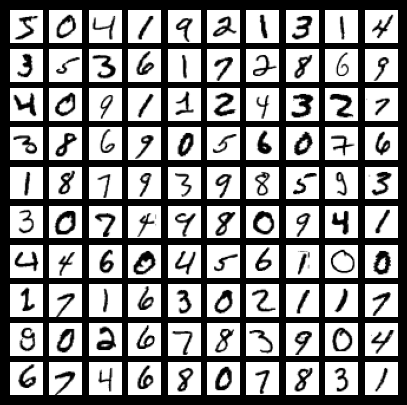

In [10]:
# display sample of digits
fig, axis = plt.subplots(10, 10, figsize=(5, 5))
labels = ""
for i, ax in enumerate(axis.flat):
    example_digit = X[i].reshape(28, 28)
    labels = labels + f"{y[i]}, "
    ax.imshow(example_digit, cmap='binary');
    ax.axis("off")
# print(labels)

Histogram of labels

### Evaluate distribution of figures

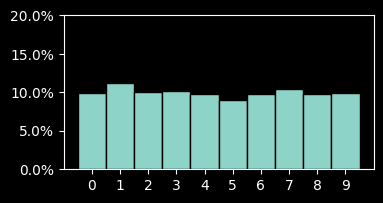

In [11]:
yy = np.sort(y)
plt.figure(figsize=(4, 2))
plt.hist(yy, weights=np.ones(len(y)) / len(y), bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], align="left", edgecolor = "black")
plt.ylim(0.0, 0.2)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

### Create training and test sets

Training set = first 60,0000; Test set = last 10,000 images

**Note:** the training set is already shuffled

In [20]:
from sklearn.model_selection import train_test_split

# flatten image data
n_samples = len(X)
X = X.reshape((n_samples, -1))

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

X_train = X_train[:2000]
y_train = y_train[:2000]

### Select and Train a Model

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.linear_model import SGDClassifier

In [15]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter("ignore", category=ConvergenceWarning)

Creating a basic preprocessing pipline with a chosen model

In [26]:
preprocessing = make_pipeline(StandardScaler())

sgd_classifier_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("SGD_Classifier", SGDClassifier(random_state=42)),
])

Trainig score before using Grid Search

In [ ]:
sgd_accuracy = cross_val_score(
    sgd_classifier_pipeline, 
    X_train, 
    y_train, 
    cv=3, # 3-fold cross validation (trains the pipeline 3x times) 
    scoring="accuracy"
)
print(sgd_accuracy)

[0.83058471 0.81109445 0.85585586]


Apply Grid Search to find good parameters

In [31]:
from sklearn.model_selection import GridSearchCV

In [32]:
param_grid = [
    {
        'SGD_Classifier__loss': ["hinge", "log_loss", "modified_huber"],
         "SGD_Classifier__alpha": [1e-4, 1e-3, 1e-2],
    },
]

In [ ]:
grid_search = GridSearchCV(
    sgd_classifier_pipeline, 
    param_grid, 
    cv=3, 
    scoring="accuracy"
)
grid_search.fit(X_train, y_train)
print(grid_search.best_estimator_)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('standardscaler', StandardScaler())])),
                ('SGD_Classifier',
                 SGDClassifier(alpha=0.01, loss='log_loss', random_state=42))])


In [37]:
print(grid_search.best_params_ )
print(grid_search.best_score_)
print(grid_search.best_estimator_.score(X_test, y_test))

{'SGD_Classifier__alpha': 0.01, 'SGD_Classifier__loss': 'log_loss'}
0.8440089264676972
0.8737142857142857


Comparing Confusing Matrix's

Pre-GridSearch


<Figure size 640x480 with 0 Axes>

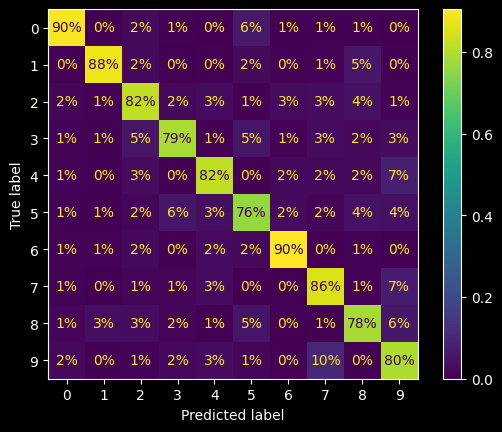

Post-GridSearch


<Figure size 640x480 with 0 Axes>

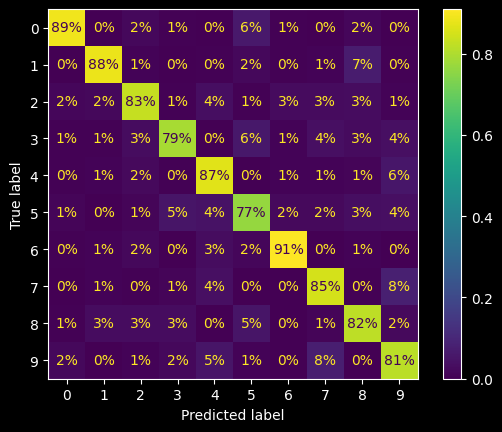

In [ ]:
# basic pipeline
basic_y_train_predictions = cross_val_predict(
    sgd_classifier_pipeline, 
    X_train,
    y_train, 
    cv=3,
)

print("Pre-GridSearch")
plt.figure()
ConfusionMatrixDisplay.from_predictions(
    y_train, basic_y_train_predictions, normalize="true", values_format=".0%"
    )
plt.show()

# optimised pipeline

opt_sgd_classifier_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("SGD_Classifier", SGDClassifier(random_state=42, alpha=0.01, loss='log_loss')),
])

opt_y_train_predictions = cross_val_predict(
    opt_sgd_classifier_pipeline, 
    X_train, 
    y_train, 
    cv=3,
)

print("Post-GridSearch")
plt.figure()
ConfusionMatrixDisplay.from_predictions(
    y_train, opt_y_train_predictions, normalize="true", values_format=".0%"
    )
plt.show()
